In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import xarray as xr

# import os
import sys
sys.path.append('..')
from hypso.hypso2 import Hypso2
from hypso.hypso1 import Hypso1

# Load HYPSO-1 and HYPSO-2 datacubes

In [2]:
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'

In [3]:
satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)
satobj_h2 = Hypso2(path=l1a_nc_file_h2, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] No georeferencing .points file provided. Skipping georeferencing.
[INFO] Loading L1a capture lacrau_2024-12-26T11-15-54Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide


In [4]:
l1a_cube_h1 = np.array(satobj_h1.get_l1a_cube())
l1a_cube_h2 = np.array(satobj_h2.get_l1a_cube())

In [5]:
satobj_h1.generate_l1b_cube()
satobj_h2.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...
[INFO] Running calibration routines...
[INFO] Running radiometric calibration...


In [6]:
calibrated_cube_h1 = satobj_h1.get_l1b_cube()
calibrated_cube_h2 = satobj_h2.get_l1b_cube()

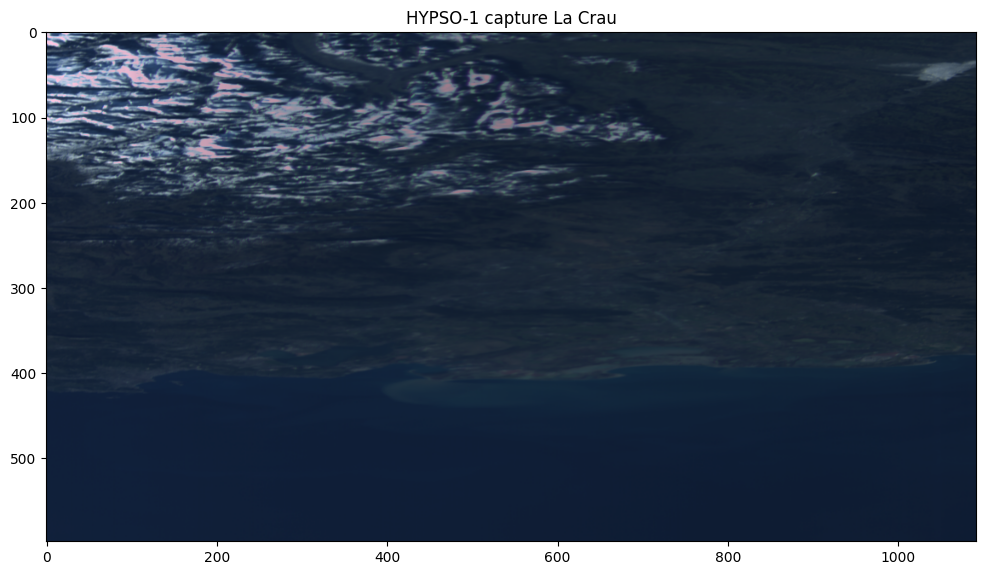

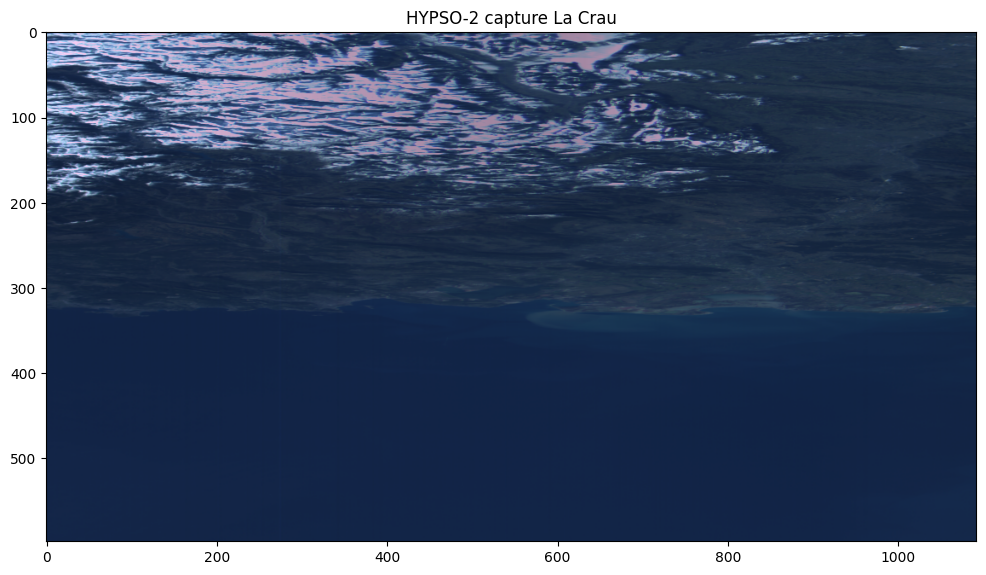

In [7]:

#R:630nm, G:550nm, B:480nm
# Red, Green, Blue, Alpha
red_wl = 630
green_wl = 550
blue_wl = 480

red_idx_h1 =   satobj_h1.get_closest_wavelength_index(red_wl)
green_idx_h1 = satobj_h1.get_closest_wavelength_index(green_wl)
blue_idx_h1 =  satobj_h1.get_closest_wavelength_index(blue_wl)

red_idx_h2 =   satobj_h2.get_closest_wavelength_index(red_wl)
green_idx_h2 = satobj_h2.get_closest_wavelength_index(green_wl)
blue_idx_h2 =  satobj_h2.get_closest_wavelength_index(blue_wl)


composite_h1 = (255*calibrated_cube_h1[:,:,[red_idx_h1, green_idx_h1, blue_idx_h1]]/calibrated_cube_h1[:,:,[red_idx_h1, green_idx_h1, blue_idx_h1]].max()).astype(int)
composite_h2 = (255*calibrated_cube_h2[:,:,[red_idx_h2, green_idx_h2, blue_idx_h2]]/calibrated_cube_h2[:,:,[red_idx_h2, green_idx_h2, blue_idx_h2]].max()).astype(int)
plt.figure(figsize=(12,12))
plt.title('HYPSO-1 capture La Crau')
plt.imshow(composite_h1)
# plt.axis('off')
plt.figure(figsize=(12,12))
plt.title('HYPSO-2 capture La Crau')
plt.imshow(composite_h2)
# plt.axis('off')

# Test ToA reflectance

In [8]:
# l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'

In [9]:
# satobj_h2 = Hypso2(path=l1a_nc_file_h2, verbose=True)

In [10]:
# satobj_h2.generate_l1b_cube()

In [11]:
satobj_h2.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 32
Quaternion samples: 32
ADCS time range: 1735211100.000000 to 1735212030.000000
Frame time range: 1735211754.537797 to 1735211829.162797
3 sample(s) inside frame time range
Interpolating 598 frames
Spatial dimensions: 598 frames/lines, 1092 pixels/samples
Computing pixel latitude and longitude coordinates...
Interpolating pixel coordinate gaps...
Using geometry-computed latitude and longitude values
Computing local angles (sun and satellite azimuth and zenith angles)...
Image Center (lat,lon): (43.58527	004.45948)
Image Center elevation angle: 38.61780
Image Center off-nadir angle: 41.60153


In [12]:
satobj_h2.generate_toa_reflectance()

toa_rrs_cube_h2 = satobj_h2.get_toa_reflectance()

In [13]:
# l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'

In [14]:
# satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)

In [15]:
# satobj_h1.generate_l1b_cube()

In [16]:
satobj_h1.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 430
Quaternion samples: 430
ADCS time range: 1735207980.000000 to 1735208940.000000
Frame time range: 1735208668.028188 to 1735208717.778188
199 sample(s) inside frame time range
Interpolating 598 frames
Spatial dimensions: 598 frames/lines, 1092 pixels/samples
Computing pixel latitude and longitude coordinates...


Interpolating pixel coordinate gaps...
Using geometry-computed latitude and longitude values
Computing local angles (sun and satellite azimuth and zenith angles)...
Image Center (lat,lon): (44.00719	004.61184)
Image Center elevation angle: 38.95816
Image Center off-nadir angle: 41.69267


In [17]:
satobj_h1.generate_toa_reflectance()

toa_rrs_cube_h1 = satobj_h1.get_toa_reflectance()

### Compare H1 and H2 (digital counts, radiance, reflectance)

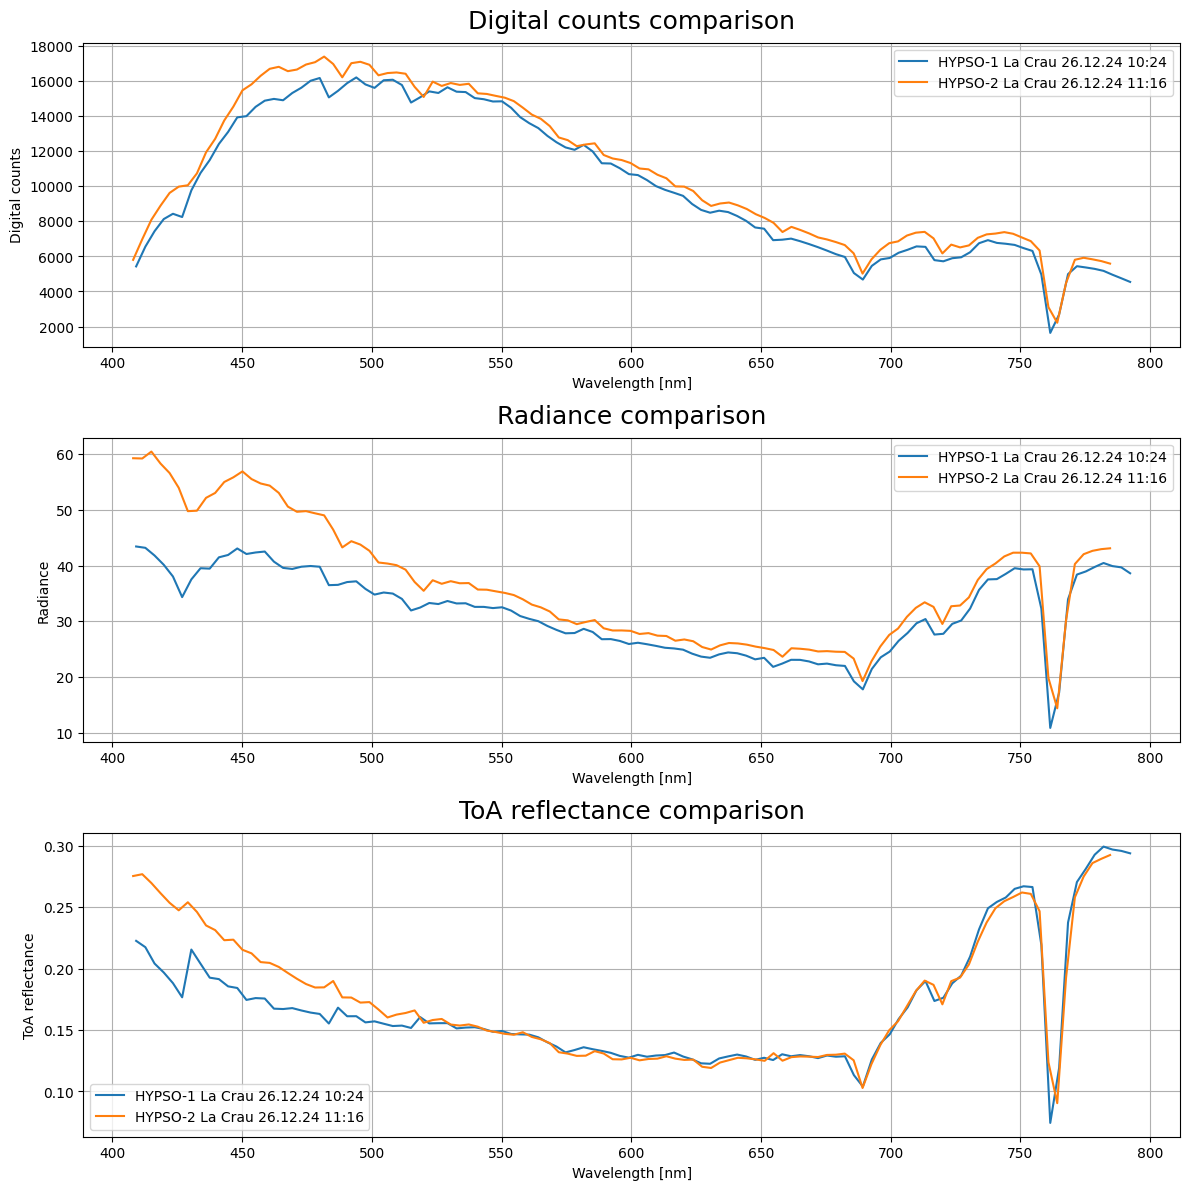

In [18]:
x_gsp_h2, y_gsp_h2 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470


plt.figure(figsize=(12,12))
plt.subplot(3,1,1)
plt.title('Digital counts comparison', fontsize=18, y=1.02)
plt.plot(satobj_h1.wavelengths[6:-3], l1a_cube_h1[x_gsp_h1, y_gsp_h1, 6:-3]) # wavelength mapping is not correct ...
plt.plot(satobj_h2.wavelengths[8:-2], l1a_cube_h2[x_gsp_h2, y_gsp_h2, 8:-2]) # wavelength mapping is not correct ...
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('Digital counts')
plt.legend([ 'HYPSO-1 La Crau 26.12.24 10:24', 'HYPSO-2 La Crau 26.12.24 11:16'])

# plt.figure(figsize=(12,6))
plt.subplot(3,1,2 )
plt.title('Radiance comparison', fontsize=18, y=1.02)
plt.plot(satobj_h1.wavelengths[6:-3], calibrated_cube_h1[x_gsp_h1, y_gsp_h1, 6:-3]) # wavelength mapping is not correct ...
plt.plot(satobj_h2.wavelengths[8:-2], calibrated_cube_h2[x_gsp_h2, y_gsp_h2, 8:-2]) # wavelength mapping is not correct ...
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('Radiance')
plt.legend([ 'HYPSO-1 La Crau 26.12.24 10:24', 'HYPSO-2 La Crau 26.12.24 11:16'])

# plt.figure(figsize=(12,6))
plt.subplot(3,1,3)
plt.title('ToA reflectance comparison', fontsize=18, y=1.02)
plt.plot(satobj_h1.wavelengths[6:-3], toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, 6:-3]) # wavelength mapping is not correct ...
plt.plot(satobj_h2.wavelengths[8:-2], toa_rrs_cube_h2[x_gsp_h2, y_gsp_h2, 8:-2]) # wavelength mapping is not correct ...
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA reflectance')
plt.legend([ 'HYPSO-1 La Crau 26.12.24 10:24', 'HYPSO-2 La Crau 26.12.24 11:16'])

plt.tight_layout()

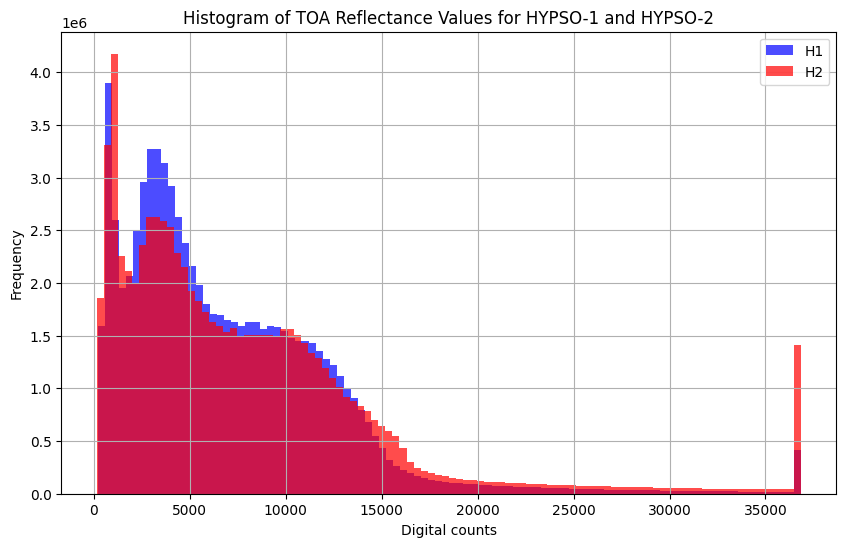

In [19]:
# compare number of pixels with each digital count H1 and H2

# Flatten the data array to 1D for histogram plotting
l1a_values_h1 = np.array(l1a_cube_h1).flatten()
l1a_values_h2 = np.array(l1a_cube_h2).flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(l1a_values_h1, bins=100, color='blue', alpha=0.7)
plt.hist(l1a_values_h2, bins=100, color='red', alpha=0.7)
plt.title('Histogram of TOA Reflectance Values for HYPSO-1 and HYPSO-2')
plt.legend(['H1', 'H2'])
plt.xlabel('Digital counts')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Load RadCalNet

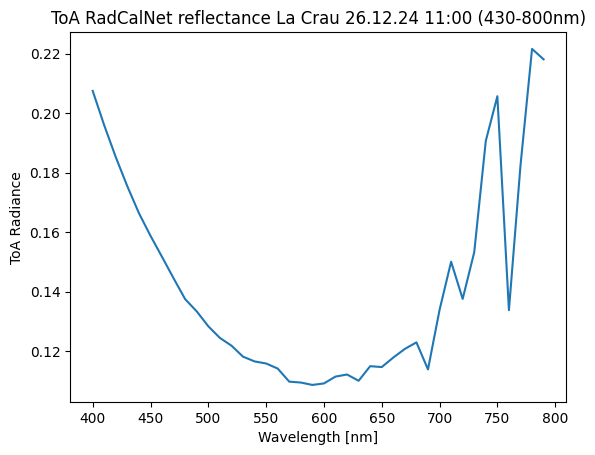

In [20]:
# Read the ASCII ToA data

file_path = '../../data/h2_lacrau_2024-12-26T11-15-54/RadCalNet/LCFR01_2024_361_v04.06.output'

def read_radcalnet_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize variables to store header and data
    header = []
    atmos_data = []
    ToA_reflectance = []
    ToA_uncertainty = []

    # State variable to track which part of the file we are reading
    state = 'header'

    for line in lines:
        stripped_line = line.strip()
        
        if state == 'header':
            if stripped_line == '':
                state = 'atmos_data'
            else:
                split_line = stripped_line.split('\t')
                header.append(split_line)
        elif state == 'atmos_data':
            if stripped_line == '':
                state = 'ToA_reflectance'
            else:
                split_line = stripped_line.split('\t')
                atmos_data.append(split_line)
        elif state == 'ToA_reflectance':
            if stripped_line == '' and len(ToA_reflectance) != 0:
                state = 'ToA_uncertainty'
            else:
                if stripped_line != '':
                    split_line = stripped_line.split('\t')
                    ToA_reflectance.append(split_line)
        elif state == 'ToA_uncertainty':
            if stripped_line != '':
                split_line = stripped_line.split('\t')
                ToA_uncertainty.append(split_line)
    header_ar = np.array(header)
    atmos_data_ar = np.array(atmos_data)
    ToA_reflectance_ar = np.array(ToA_reflectance, dtype=float)
    ToA_uncertainty_ar = np.array(ToA_uncertainty)


    return header_ar, atmos_data_ar, ToA_reflectance_ar, ToA_uncertainty_ar

header, atmos_data, ToA_reflectance, ToA_uncertainty = read_radcalnet_file(file_path)

plt.figure()
plt.title('ToA RadCalNet reflectance La Crau 26.12.24 11:00 (430-800nm)')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Radiance')
plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])

### Plot

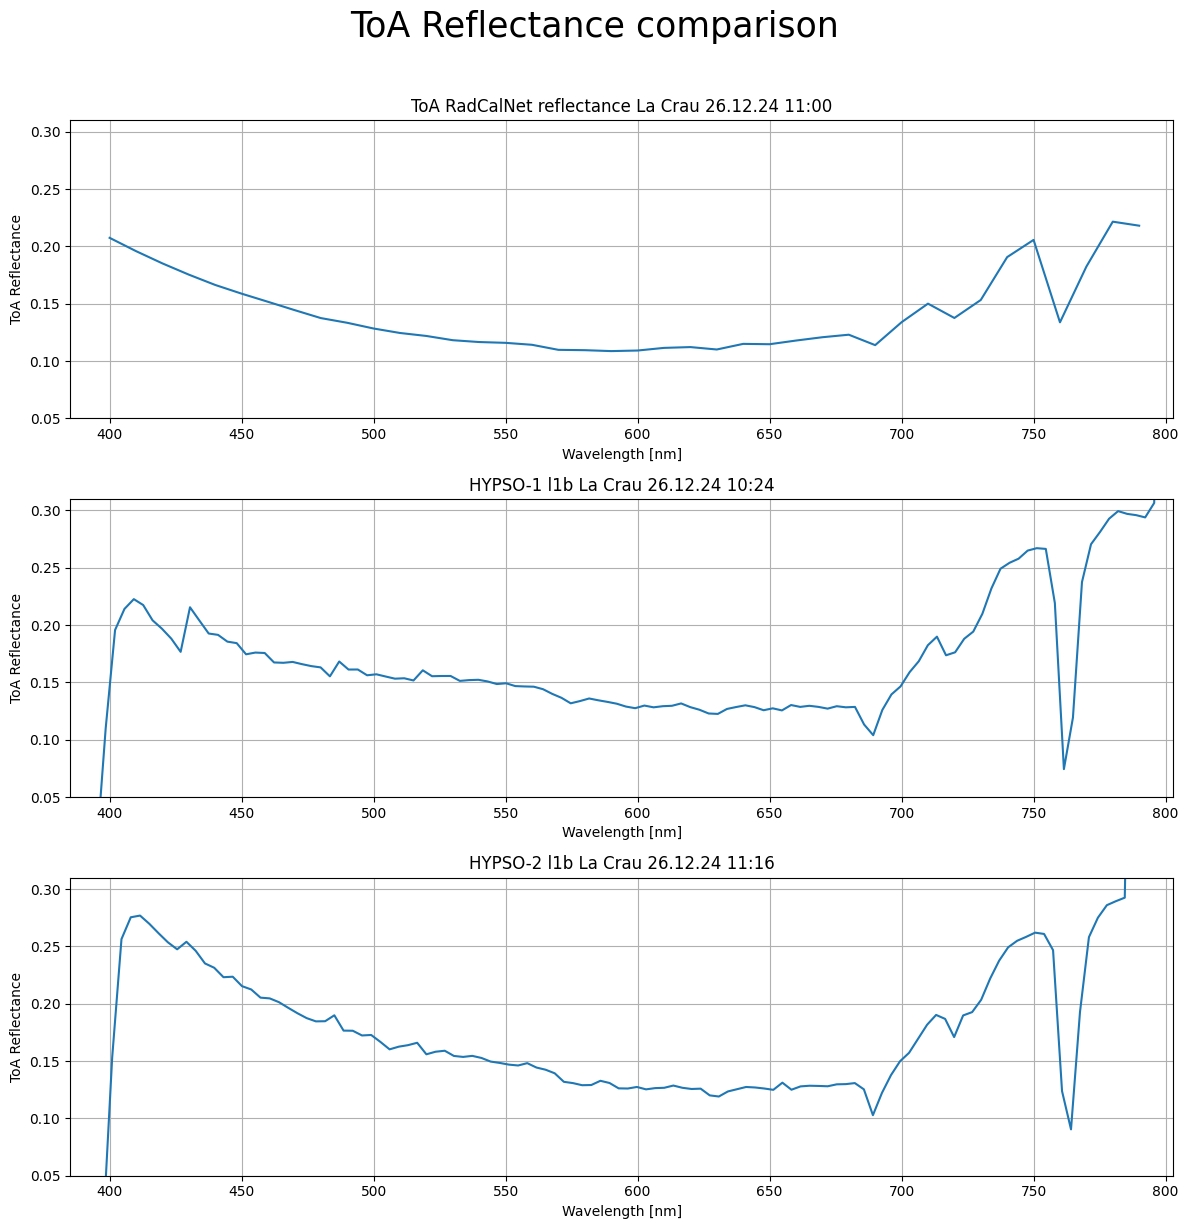

In [21]:
x_gsp_h2, y_gsp_h2 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470

# manually found x and y limits for this particular case
x_limits = 385, 803
y_limits = 0.05, 0.31
# y_limits = 0.08, 0.3


plt.figure(figsize=(12,12))
plt.suptitle('ToA Reflectance comparison', fontsize=25, y=1.02)
plt.subplot(3,1,1)
plt.title('ToA RadCalNet reflectance La Crau 26.12.24 11:00')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.grid()
plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])
plt.xlim(x_limits)
plt.ylim(y_limits)

plt.subplot(3,1,2)
plt.title('HYPSO-1 l1b La Crau 26.12.24 10:24')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.plot(satobj_h1.wavelengths[:], toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, :]) # wavelength mapping is not correct ...
plt.xlim(x_limits)
plt.ylim(y_limits)
plt.grid()

plt.subplot(3,1,3)
plt.title('HYPSO-2 l1b La Crau 26.12.24 11:16')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.plot(satobj_h2.wavelengths[:], toa_rrs_cube_h2[x_gsp_h2, y_gsp_h2, :]) # wavelength mapping is not correct ...
plt.xlim(x_limits)
plt.ylim(y_limits)
plt.grid()

plt.tight_layout()


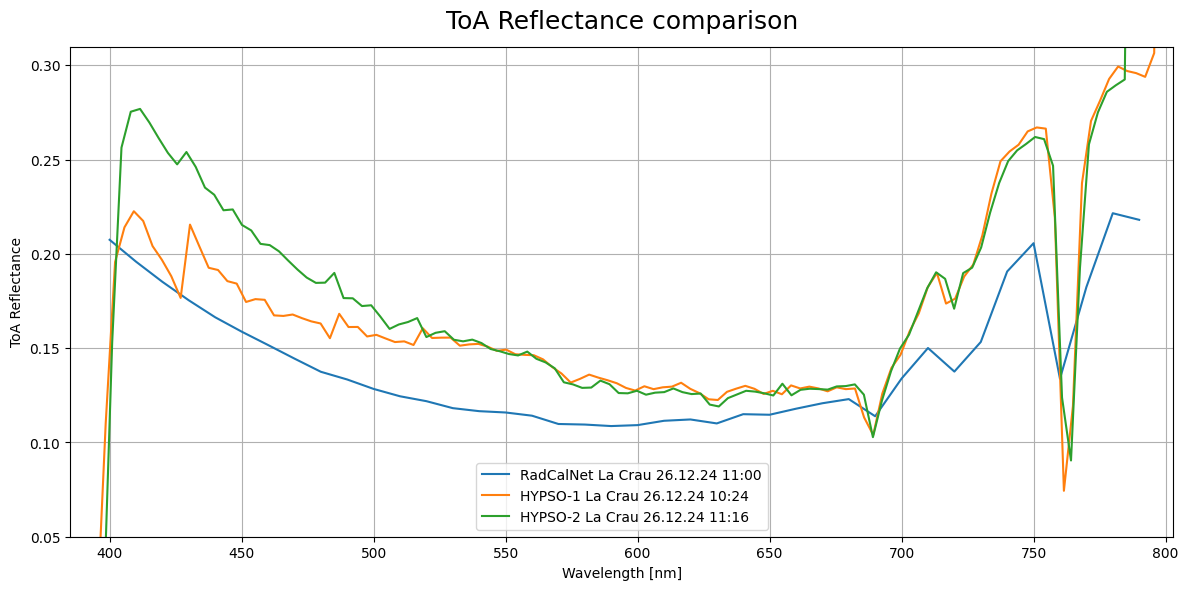

In [22]:
x_gsp_h2, y_gsp_h2 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470

# manually found x and y limits for this particular case
x_limits = 385, 803
y_limits = 0.05, 0.31
# y_limits = 0.08, 0.3


plt.figure(figsize=(12,6))
plt.title('ToA Reflectance comparison', fontsize=18, y=1.02)
plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])
plt.plot(satobj_h1.wavelengths[:], toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, :]) # wavelength mapping is not correct ...
plt.plot(satobj_h2.wavelengths[:], toa_rrs_cube_h2[x_gsp_h2, y_gsp_h2, :]) # wavelength mapping is not correct ...
plt.xlim(x_limits)
plt.ylim(y_limits)
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.legend(['RadCalNet La Crau 26.12.24 11:00', 'HYPSO-1 La Crau 26.12.24 10:24', 'HYPSO-2 La Crau 26.12.24 11:16'])

plt.tight_layout()


### Find absoption bands

764.1785207381841


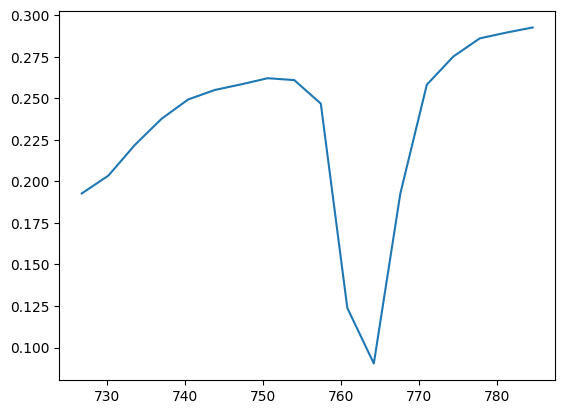

In [23]:
plt.plot(satobj_h2.wavelengths[100:-2], toa_rrs_cube_h2[x_gsp_h2, y_gsp_h2, 100:-2])
print( satobj_h2.wavelengths[100 + np.argmin(np.array(toa_rrs_cube_h2[x_gsp_h2, y_gsp_h2, 100:-2]))])

absorption_band_h2 = satobj_h2.wavelengths[100 + np.argmin(np.array(toa_rrs_cube_h2[x_gsp_h2, y_gsp_h2, 100:-2]))]

107
761.4854441181661


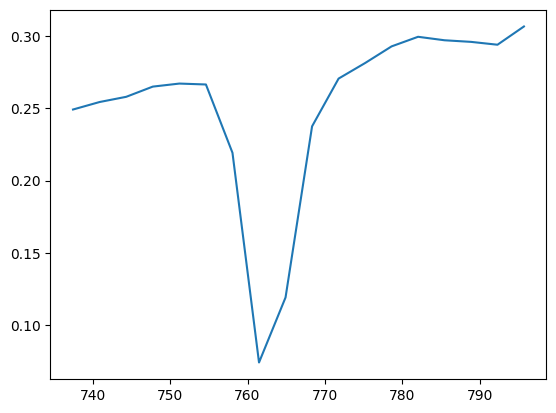

In [24]:
plt.plot(satobj_h1.wavelengths[100:-2], toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, 100:-2])
print( 100 + np.argmin(np.array(toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, 100:-2])))
print( satobj_h1.wavelengths[100 + np.argmin(np.array(toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, 100:-2]))])

absorption_band_h1 = satobj_h1.wavelengths[100 + np.argmin(np.array(toa_rrs_cube_h1[x_gsp_h1, y_gsp_h1, 100:-2]))]

760.0


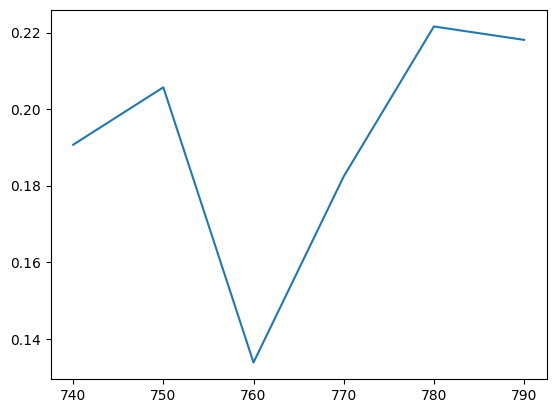

In [25]:
plt.plot(ToA_reflectance[34:40,0], ToA_reflectance[34:40, 4])
print( ToA_reflectance[34 + np.argmin(ToA_reflectance[34:40, 4]),0])

absorption_band_rad = ToA_reflectance[34 + np.argmin(ToA_reflectance[34:40, 4]),0]

### compare bands

In [26]:
print('Hypso-1:', absorption_band_h1)
print('Hypso-2:', absorption_band_h2)
print('RadCalNet:', absorption_band_rad)

Hypso-1: 761.4854441181661
Hypso-2: 764.1785207381841
RadCalNet: 760.0


# Check NetCDF

In [ ]:
from netCDF4 import Dataset

# specify the path to your netCDF file
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'
# l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-l1a.nc'

# open the NetCDF file
nc_file_h1 = Dataset(l1a_nc_file_h1, mode='r')
nc_file_h2 = Dataset(l1a_nc_file_h2, mode='r')

# print timestamps min and max values
print('min and max timestamp h1 capture: ', nc_file_h1.groups['metadata'].groups['adcs'].variables['timestamps'][:].min(), nc_file_h1.groups['metadata'].groups['adcs'].variables['timestamps'][:].max()) # seems like h2 is missing a good bit of the adcs metadata
print('min and max timestamp h2 capture: ', nc_file_h2.groups['metadata'].groups['adcs'].variables['timestamps'][:].min(), nc_file_h2.groups['metadata'].groups['adcs'].variables['timestamps'][:].max()) # seems like h2 is missing a good bit of the adcs metadata

print(nc_file_h1.groups['metadata'].groups.keys())
# close the file
# nc_file_h1.close()
# nc_file_h2.close()

In [ ]:
import pandas as pd

quaternion_file_h2 = "h2_quaternion.csv"
quaternion_data_h2 = pd.read_csv(quaternion_file_h2)
position_file_h2 = "h2_position.csv"
position_data_h2 = pd.read_csv(position_file_h2)


timestamps = np.array(quaternion_data_h2['timestamp'][:])
quaternion_s = np.array(quaternion_data_h2['quat_0'][:])
quaternion_x = np.array(quaternion_data_h2['quat_1'][:])
quaternion_y = np.array(quaternion_data_h2['quat_2'][:])
quaternion_z = np.array(quaternion_data_h2['quat_3'][:])
control_error = np.array(quaternion_data_h2['Control error [deg]'][:])
position_x = np.array(position_data_h2['eci x [m]'][:])
position_y = np.array(position_data_h2['eci y [m]'][:])
position_z = np.array(position_data_h2['eci z [m]'][:])


print(position_z)   

# Test georeferencing

hvordan korresponderer timestamps i .csv fila med de i netcdf fila???

In [33]:
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'
points_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-scaled_test.points'
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'
points_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-scaled_test.points'

# try h2 capture with higher adcs sampling rate
# l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-l1a.nc'
# points_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-scaled.points'
# points_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-scaled_mercator.points'

In [ ]:
# use h1 object just to get the wavelengths
# satobj_h1 = Hypso1(path=l1a_nc_file_h1, points_path=points_h1,  verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] Running georeferencing...
No image mode provided. Detected image mode: bin3
[INFO] Using UTM map: WGS 84 / UTM zone 31N EPSG: 32631


In [ ]:
# satobj_h1.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...


KeyboardInterrupt: 

In [ ]:
# l1a_scene_h1 = satobj_h1.get_l1a_satpy_scene()

In [ ]:
# satobj_h2 = Hypso1(path=l1a_nc_file_h2, points_path=points_h2,  verbose=True)

In [ ]:
# l1a_scene_h2 = satobj_h2.get_l1a_satpy_scene()

## test if .points file worked

In [ ]:
# satobj_h2.generate_geometry()

In [ ]:
# satobj_h2.generate_geometry()

In [ ]:
# satobj_h1.generate_toa_reflectance()

# toa_rrs_cube = satobj_h1.get_toa_reflectance()

In [ ]:
# toa_rrs_cube

In [ ]:
# lat =  satobj_h1.latitudes[0, 0] #[200,500]
# lon = satobj_h1.longitudes[0, 0] #[200,500]

# l1a_spectrum = satobj_h1.get_l1a_spectrum(latitude=lat, longitude=lon)

# satobj_h1.plot_l1a_spectrum(latitude=lat, longitude=lon)


## Load area definition

In [ ]:
# from pyresample import load_area
# area_def = load_area("./lacrau_demo.yaml")

## Resample capture to area definition

In [ ]:
# resampled_l1a_scene_h1 = l1a_scene_h1.resample(area_def, resampler='bilinear', fill_value=np.nan)

## Create resampled RGB composite from L1A cube

In [ ]:
# import satpy
# from satpy.composites import GenericCompositor
# from satpy.writers import to_image

# # RGB Hypso image
# compositor = GenericCompositor("rgb")

# #R:630nm, G:550nm, B:480nm
# # Red, Green, Blue, Alpha
# red_wl = 630
# green_wl = 550
# blue_wl = 480

# red_idx =   satobj_h1.get_closest_wavelength_index(red_wl)
# green_idx = satobj_h1.get_closest_wavelength_index(green_wl)
# blue_idx =  satobj_h1.get_closest_wavelength_index(blue_wl)

# red_band =   'band_' + str(red_idx)
# green_band = 'band_' + str(green_idx)
# blue_band =  'band_' + str(blue_idx)
# alpha_band = 'band_' + str(blue_idx)

# composite = compositor([resampled_l1a_scene_h1[red_band], 
#                         resampled_l1a_scene_h1[green_band], 
#                         resampled_l1a_scene_h1[blue_band], 
#                         resampled_l1a_scene_h1[alpha_band]]) 

# rgb_img = to_image(composite) 
# rgb_img.stretch_linear()
# rgb_img.gamma(1.2)

# rgb_xr_image = rgb_img

# rgb_img = rgb_img.pil_image()

In [ ]:
# rgb_img

In [ ]:
# rgb_img.save('./' + satobj_h2.capture_name + '_rgb_resampled.png')